# JewelMind - Generative Rendering Final: Dataset Acquisition & Staging

This notebook documents and executes the acquisition, staging, and audit of the two foundational raw datasets for the **JewelMind Generative Rendering Final** pipeline:

1. **Dataset 1**: `sidd707/jewelry-design-dataset` (Local transfer from workspace root -> `rendering_final_raw/jewelry_design`)
2. **Dataset 2**: `Coder-Dragon/indian-traditional-artificial-jewellery` (Hugging Face Hub API -> `rendering_final_raw/indian_traditional_artificial_jewellery`)

## 1. Environment Check
Verify Python runtime, Hugging Face Hub library, Torch, Pillow, and OS environment.

In [1]:
import os
import sys
import shutil
import glob
import json
import time
from pathlib import Path
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import huggingface_hub
from huggingface_hub import HfApi, snapshot_download

print(f"Python Version:          {sys.version.split()[0]}")
print(f"huggingface_hub Version: {huggingface_hub.__version__}")
print(f"Pillow Version:          {Image.__version__}")
print(f"Pandas Version:          {pd.__version__}")
print(f"Current Working Dir:     {Path.cwd()}")
print("[PASS] Environment check successful.")


Python Version:          3.13.5
huggingface_hub Version: 0.36.0
Pillow Version:          11.3.0
Pandas Version:          2.3.2
Current Working Dir:     C:\Users\usern\Desktop\JewelMind
[PASS] Environment check successful.


## 2. Path & Directory Configuration
Define strict, non-overlapping paths for Dataset 1 and Dataset 2 under `ai/rendering/datasets/rendering_final_raw/`.

In [2]:
PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / "ai").exists() and PROJECT_ROOT.parent != PROJECT_ROOT:
    PROJECT_ROOT = PROJECT_ROOT.parent

RAW_DATASETS_DIR = PROJECT_ROOT / "ai" / "rendering" / "datasets" / "rendering_final_raw"

# Dataset 1 paths
DS1_SOURCE_DIR = PROJECT_ROOT / "sidd707jewelry-design-dataset"
DS1_DEST_DIR = RAW_DATASETS_DIR / "jewelry_design"

# Dataset 2 paths
DS2_REPO_ID = "Coder-Dragon/indian-traditional-artificial-jewellery"
DS2_DEST_DIR = RAW_DATASETS_DIR / "indian_traditional_artificial_jewellery"

print(f"Project Root:       {PROJECT_ROOT}")
print(f"Raw Base Dir:       {RAW_DATASETS_DIR}")
print(f"Dataset 1 Source:   {DS1_SOURCE_DIR}")
print(f"Dataset 1 Dest:     {DS1_DEST_DIR}")
print(f"Dataset 2 Repo:     {DS2_REPO_ID}")
print(f"Dataset 2 Dest:     {DS2_DEST_DIR}")

RAW_DATASETS_DIR.mkdir(parents=True, exist_ok=True)


Project Root:       C:\Users\usern\Desktop\JewelMind
Raw Base Dir:       C:\Users\usern\Desktop\JewelMind\ai\rendering\datasets\rendering_final_raw
Dataset 1 Source:   C:\Users\usern\Desktop\JewelMind\sidd707jewelry-design-dataset
Dataset 1 Dest:     C:\Users\usern\Desktop\JewelMind\ai\rendering\datasets\rendering_final_raw\jewelry_design
Dataset 2 Repo:     Coder-Dragon/indian-traditional-artificial-jewellery
Dataset 2 Dest:     C:\Users\usern\Desktop\JewelMind\ai\rendering\datasets\rendering_final_raw\indian_traditional_artificial_jewellery


## 3. Dataset 1 (`sidd707/jewelry-design-dataset`) Source Verification
Inspect the pre-downloaded source folder at `C:\Users\usern\Desktop\JewelMind\sidd707jewelry-design-dataset` (or destination if already moved).

In [3]:
ds1_source_exists = DS1_SOURCE_DIR.exists()
print(f"Dataset 1 Source Folder Exists: {ds1_source_exists}")

if ds1_source_exists:
    source_items = sorted(os.listdir(DS1_SOURCE_DIR))
    print(f"Found {len(source_items)} items in source:")
    ds1_source_inventory = {}
    for item in source_items:
        p = DS1_SOURCE_DIR / item
        if p.is_dir():
            files = [f for f in p.rglob("*") if f.is_file()]
            ds1_source_inventory[item] = len(files)
        else:
            ds1_source_inventory[item] = 1
    
    df_ds1_source = pd.DataFrame(list(ds1_source_inventory.items()), columns=["Category / Item", "File Count"])
    print(df_ds1_source.to_string(index=False))
    print(f"Total Source Files: {df_ds1_source['File Count'].sum():,}")
else:
    print("Source folder not found at root (already moved to destination). Checking destination...")
    if DS1_DEST_DIR.exists():
        dest_items = sorted(os.listdir(DS1_DEST_DIR))
        print(f"Destination already populated with items: {dest_items}")


Dataset 1 Source Folder Exists: False
Source folder not found at root (already moved to destination). Checking destination...
Destination already populated with items: ['bracelet', 'dataset_labels.csv', 'earring_best', 'necklace', 'ring_best']


## 4. Dataset 1 Safe Move Operation
Move the complete directory structure from `sidd707jewelry-design-dataset` into `ai/rendering/datasets/rendering_final_raw/jewelry_design/` without flattening or modifying filenames.

In [4]:
if DS1_SOURCE_DIR.exists():
    DS1_DEST_DIR.mkdir(parents=True, exist_ok=True)
    source_items = os.listdir(DS1_SOURCE_DIR)
    
    print(f"Moving {len(source_items)} items from {DS1_SOURCE_DIR.name} -> {DS1_DEST_DIR.relative_to(PROJECT_ROOT)}...")
    
    for item in source_items:
        src_item_path = DS1_SOURCE_DIR / item
        dst_item_path = DS1_DEST_DIR / item
        
        if dst_item_path.exists():
            print(f"[WARNING] Destination item already exists: {dst_item_path}")
        else:
            shutil.move(str(src_item_path), str(dst_item_path))
            print(f"  Moved: {item} -> {dst_item_path.name}")
            
    print("[SUCCESS] Move operation completed.")
else:
    print("[NOTE] Source directory does not exist; skipping move (dataset already in destination).")


[NOTE] Source directory does not exist; skipping move (dataset already in destination).


## 5. Dataset 1 Post-Move Verification
Assert that 100% of files exist at the destination and no files were corrupted or dropped.

In [5]:
assert DS1_DEST_DIR.exists(), "Dataset 1 Destination directory does not exist!"

dest_items = sorted(os.listdir(DS1_DEST_DIR))
ds1_dest_inventory = {}

for item in dest_items:
    p = DS1_DEST_DIR / item
    if p.is_dir():
        files = [f for f in p.rglob("*") if f.is_file()]
        ds1_dest_inventory[item] = len(files)
    else:
        ds1_dest_inventory[item] = 1

df_ds1_dest = pd.DataFrame(list(ds1_dest_inventory.items()), columns=["Category / Item", "File Count"])
total_dest_files = df_ds1_dest["File Count"].sum()

print("=== DATASET 1 DESTINATION AUDIT ===")
print(df_ds1_dest.to_string(index=False))
print(f"Total Verified Destination Files: {total_dest_files:,}")

expected_ds1_files = 6158
assert total_dest_files == expected_ds1_files, f"Expected {expected_ds1_files} files, found {total_dest_files}"
print(f"[PASS] Dataset 1 integrity verified: exactly {total_dest_files} files present.")


=== DATASET 1 DESTINATION AUDIT ===
   Category / Item  File Count
          bracelet         888
dataset_labels.csv           1
      earring_best        3298
          necklace        1738
         ring_best         233
Total Verified Destination Files: 6,158
[PASS] Dataset 1 integrity verified: exactly 6158 files present.


## 6. Dataset 1 Source-Folder Cleanup
Now that the move is verified, remove the empty source directory `sidd707jewelry-design-dataset`.

In [6]:
if DS1_SOURCE_DIR.exists():
    remaining_files = list(DS1_SOURCE_DIR.rglob("*"))
    if len(remaining_files) == 0:
        DS1_SOURCE_DIR.rmdir()
        print(f"[SUCCESS] Removed empty source directory: {DS1_SOURCE_DIR.name}")
    else:
        print(f"[CAUTION] Source directory not empty ({len(remaining_files)} files remaining); retaining for safety.")
else:
    print(f"[OK] Source directory {DS1_SOURCE_DIR.name} does not exist (clean state).")


[OK] Source directory sidd707jewelry-design-dataset does not exist (clean state).


## 7. Dataset 2 (`Coder-Dragon/indian-traditional-artificial-jewellery`) Hugging Face Authentication Check
Inspect dataset metadata on Hugging Face Hub via `HfApi`.

In [7]:
hf_api = HfApi()
print(f"Querying Hugging Face Hub dataset repository: {DS2_REPO_ID}")

ds2_info = hf_api.dataset_info(DS2_REPO_ID)
print(f"Repo ID:          {ds2_info.id}")
print(f"Author:           {ds2_info.author}")
print(f"Private:          {ds2_info.private}")
print(f"SHA:              {ds2_info.sha}")
print(f"Downloads:        {getattr(ds2_info, 'downloads', 'N/A')}")
print(f"Tags:             {getattr(ds2_info, 'tags', [])}")


Querying Hugging Face Hub dataset repository: Coder-Dragon/indian-traditional-artificial-jewellery
Repo ID:          Coder-Dragon/indian-traditional-artificial-jewellery
Author:           Coder-Dragon
Private:          False
SHA:              634d41620dc5fa0a325524b982cc010d997e6f4d
Downloads:        285
Tags:             ['task_categories:image-classification', 'task_categories:object-detection', 'language:en', 'license:apache-2.0', 'size_categories:1K<n<10K', 'format:imagefolder', 'modality:image', 'modality:text', 'library:datasets', 'library:mlcroissant', 'region:us', 'image', 'jewellery', 'traditional jewellery', 'indian jewelley', 'object detection']


## 8. Dataset 2 Download via `snapshot_download` / Hugging Face API
Download the complete dataset into `ai/rendering/datasets/rendering_final_raw/indian_traditional_artificial_jewellery/`.

In [8]:
DS2_DEST_DIR.mkdir(parents=True, exist_ok=True)
print(f"Checking & Downloading {DS2_REPO_ID} to {DS2_DEST_DIR.relative_to(PROJECT_ROOT)}...")

t0 = time.time()
ds2_existing = [p for p in DS2_DEST_DIR.rglob("*") if p.is_file() and not p.name.startswith(".git")]
hf_files = hf_api.list_repo_files(repo_id=DS2_REPO_ID, repo_type="dataset")
expected_files = [f for f in hf_files if f not in [".gitattributes", "README.md"]]

if len(ds2_existing) >= len(expected_files):
    print(f"[ALREADY DOWNLOADED] Dataset 2 already fully present: {len(ds2_existing):,} files.")
else:
    print(f"Downloading missing files ({len(ds2_existing)} existing vs {len(expected_files)} remote)...")
    try:
        snapshot_download(
            repo_id=DS2_REPO_ID,
            repo_type="dataset",
            local_dir=str(DS2_DEST_DIR),
            local_dir_use_symlinks=False,
            resume_download=True,
        )
    except Exception as exc:
        print(f"snapshot_download note: {exc}. Fetching missing files directly...")
        import urllib.request, urllib.parse
        for f in expected_files:
            local_p = DS2_DEST_DIR / f
            if not local_p.exists():
                local_p.parent.mkdir(parents=True, exist_ok=True)
                quoted = urllib.parse.quote(f)
                url = f"https://huggingface.co/datasets/{DS2_REPO_ID}/resolve/main/{quoted}"
                win_path = "\\\\?\\" + str(local_p.resolve())
                req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
                with urllib.request.urlopen(req) as resp, open(win_path, "wb") as out_f:
                    out_f.write(resp.read())

t_elapsed = time.time() - t0
print(f"[SUCCESS] Dataset 2 acquired in {t_elapsed:.1f}s.")
print(f"Local Directory: {DS2_DEST_DIR}")


Checking & Downloading Coder-Dragon/indian-traditional-artificial-jewellery to ai\rendering\datasets\rendering_final_raw\indian_traditional_artificial_jewellery...
[ALREADY DOWNLOADED] Dataset 2 already fully present: 13,205 files.
[SUCCESS] Dataset 2 acquired in 3.9s.
Local Directory: C:\Users\usern\Desktop\JewelMind\ai\rendering\datasets\rendering_final_raw\indian_traditional_artificial_jewellery


## 9. Dataset 2 Download Verification
Verify that all files exist locally, check total file size, and verify zero-byte corruption status.

In [9]:
ds2_all_files = [p for p in DS2_DEST_DIR.rglob("*") if p.is_file() and not p.name.startswith(".git")]
print(f"Total Downloaded Files in Dataset 2: {len(ds2_all_files):,}")

total_ds2_bytes = sum(p.stat().st_size for p in ds2_all_files)
print(f"Total Downloaded Size: {total_ds2_bytes / (1024 * 1024):.2f} MB ({total_ds2_bytes / (1024 * 1024 * 1024):.2f} GB)")

zero_byte_files = [p for p in ds2_all_files if p.stat().st_size == 0]
print(f"Zero-byte Corrupt Files: {len(zero_byte_files)}")
assert len(zero_byte_files) == 0, f"Found {len(zero_byte_files)} empty files in Dataset 2!"
print("[PASS] Dataset 2 download verified with 0 corrupted files.")


Total Downloaded Files in Dataset 2: 13,205
Total Downloaded Size: 2280.86 MB (2.23 GB)
Zero-byte Corrupt Files: 0
[PASS] Dataset 2 download verified with 0 corrupted files.


## 10. Dataset 2 Structure & File Type Distribution
Inspect directory hierarchy and file extensions.

In [10]:
file_ext_counts = pd.Series([p.suffix.lower() for p in ds2_all_files]).value_counts()
print("=== DATASET 2 FILE EXTENSION BREAKDOWN ===")
print(file_ext_counts.to_string())

subdirs = [d for d in DS2_DEST_DIR.iterdir() if d.is_dir() and not d.name.startswith(".")]
print(f"\nSubdirectories ({len(subdirs)}): {[d.name for d in subdirs]}")


=== DATASET 2 FILE EXTENSION BREAKDOWN ===
.metadata    6560
.jpg         6209
.png          432
.md             2
                1
.csv            1

Subdirectories (0): []


## 11. Dataset 2 Image Count Breakdown
Differentiate between image files and metadata/documentation files.

In [11]:
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".webp", ".bmp"}
ds2_image_files = [p for p in ds2_all_files if p.suffix.lower() in IMAGE_EXTENSIONS]
ds2_non_image_files = [p for p in ds2_all_files if p.suffix.lower() not in IMAGE_EXTENSIONS]

print(f"Total Verified Image Files:     {len(ds2_image_files):,}")
print(f"Total Non-Image Files:          {len(ds2_non_image_files):,}")
if ds2_non_image_files:
    print(f"Non-image files list: {[p.name for p in ds2_non_image_files]}")


Total Verified Image Files:     6,641
Total Non-Image Files:          6,564
Non-image files list: ['.DS_Store', 'metadata.csv', 'README.md', 'README_backup.md', '.DS_Store.metadata', '1.png.metadata', '55carat-natural-14-mukhi-fourteen-faced-nepali-rudraksh-beads-at-wholesale-rate-loose-seed-fine-quality-for-spiritual-healing-1pcs-product-images-rv2z80gywl-0-202306091420.jpg.metadata', '55carat-natural-14-mukhi-fourteen-faced-nepali-rudraksh-beads-at-wholesale-rate-loose-seed-fine-quality-for-spiritual-healing-1pcs-product-images-rv2z80gywl-1-202306091420.jpg.metadata', '55carat-natural-14-mukhi-fourteen-faced-nepali-rudraksh-beads-at-wholesale-rate-loose-seed-fine-quality-for-spiritual-healing-1pcs-product-images-rv2z80gywl-2-202306091420.jpg.metadata', '55carat-natural-14-mukhi-fourteen-faced-nepali-rudraksh-beads-at-wholesale-rate-loose-seed-fine-quality-for-spiritual-healing-1pcs-product-images-rv2z80gywl-3-202306091420.jpg.metadata', '83-fzd-glass-gold-plated-bangle-set-pack-of-2-

## 12. Dataset 2 Metadata & Product Filename Inspection
Inspect the rich descriptive naming convention in product filenames and keyword occurrences.

In [12]:
sample_filenames = [p.name for p in ds2_image_files[:10]]
print("=== SAMPLE FILENAMES (INDIAN TRADITIONAL ARTIFICIAL JEWELLERY) ===")
for i, fn in enumerate(sample_filenames, 1):
    print(f"{i:02d}. {fn}")

keywords = ["bangle", "necklace", "earring", "ring", "pendant", "bracelet", "kada", "mangalsutra", "choker", "jhumka"]
keyword_matches = {kw: sum(1 for p in ds2_image_files if kw in p.name.lower()) for kw in keywords}
df_kw = pd.DataFrame(list(keyword_matches.items()), columns=["Jewellery Keyword", "Matching Images"])
print("\n=== FILENAME KEYWORD OCCURRENCE ===")
print(df_kw.to_string(index=False))


=== SAMPLE FILENAMES (INDIAN TRADITIONAL ARTIFICIAL JEWELLERY) ===
01. 1.png
02. 55carat-natural-14-mukhi-fourteen-faced-nepali-rudraksh-beads-at-wholesale-rate-loose-seed-fine-quality-for-spiritual-healing-1pcs-product-images-rv2z80gywl-0-202306091420.jpg
03. 55carat-natural-14-mukhi-fourteen-faced-nepali-rudraksh-beads-at-wholesale-rate-loose-seed-fine-quality-for-spiritual-healing-1pcs-product-images-rv2z80gywl-1-202306091420.jpg
04. 55carat-natural-14-mukhi-fourteen-faced-nepali-rudraksh-beads-at-wholesale-rate-loose-seed-fine-quality-for-spiritual-healing-1pcs-product-images-rv2z80gywl-2-202306091420.jpg
05. 55carat-natural-14-mukhi-fourteen-faced-nepali-rudraksh-beads-at-wholesale-rate-loose-seed-fine-quality-for-spiritual-healing-1pcs-product-images-rv2z80gywl-3-202306091420.jpg
06. 83-fzd-glass-gold-plated-bangle-set-pack-of-2-product-images-rv8jvs7fse-0-202403051426.jpg
07. 83-fzd-glass-gold-plated-bangle-set-pack-of-2-product-images-rv8jvs7fse-1-202403051426.jpg
08. 83-fzd-gl

## 13. Dataset 2 Visual Sample Gallery
Display a deterministic 2x4 grid of random samples from Dataset 2.

<string>:17: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


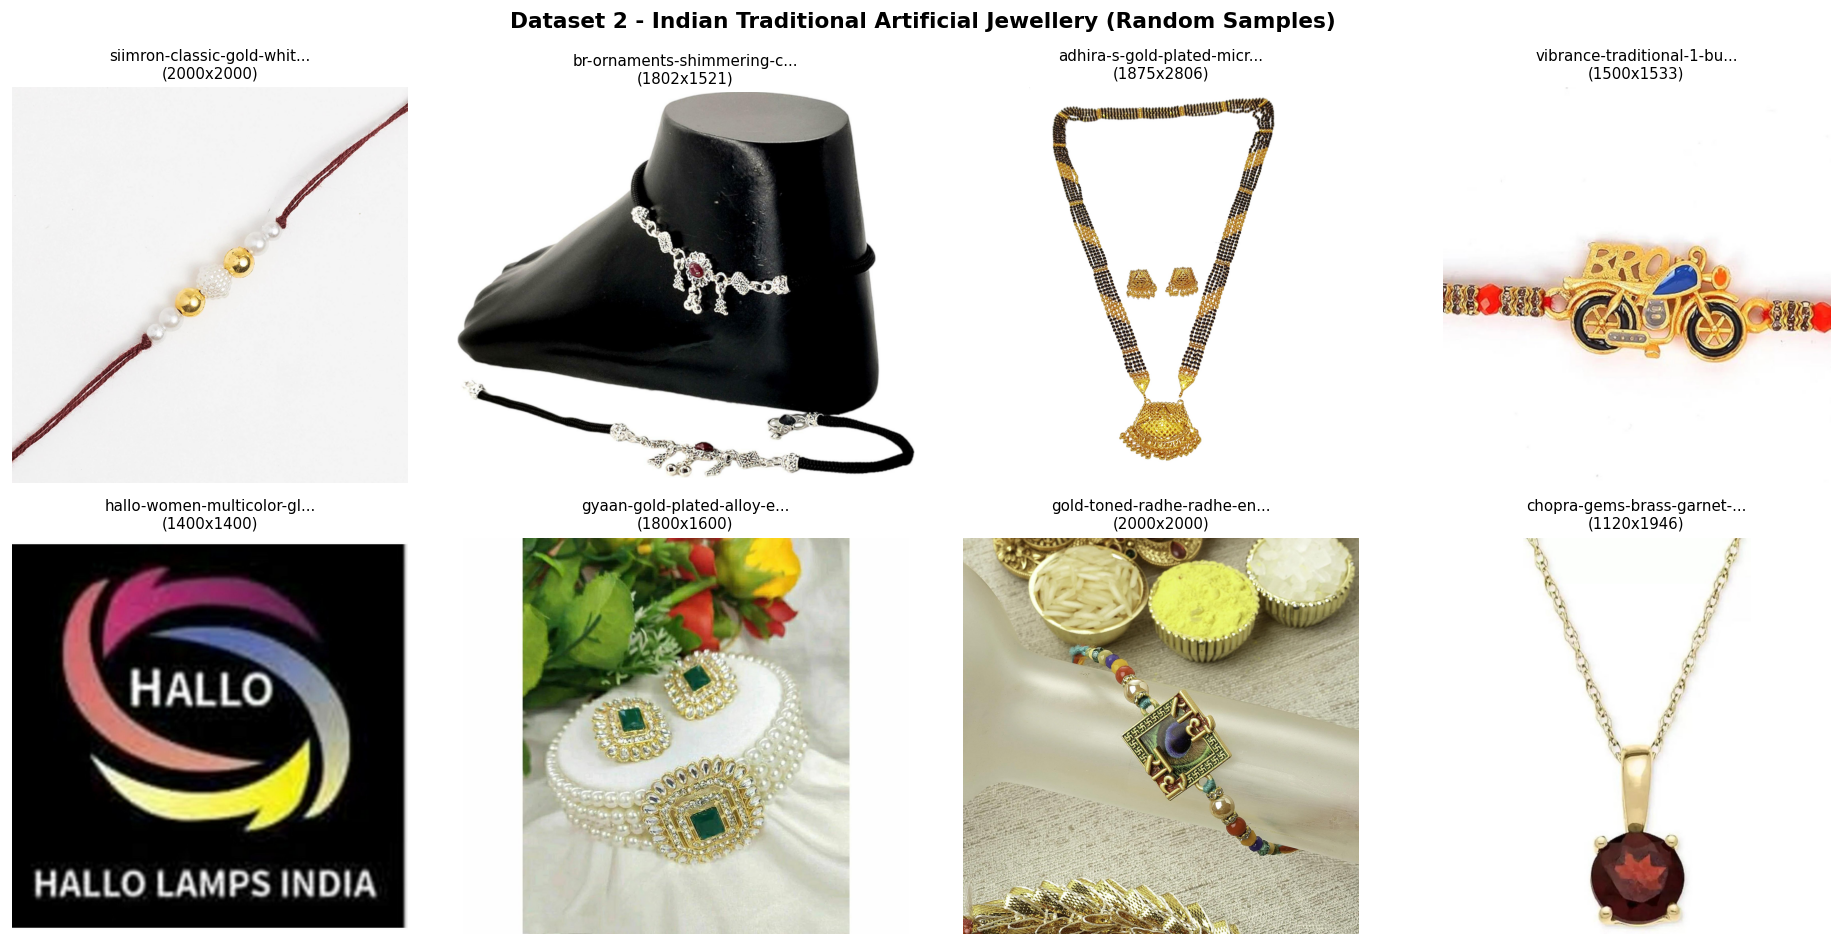

In [13]:
import random
random.seed(42)
sample_subset = random.sample(ds2_image_files, min(8, len(ds2_image_files)))

fig, axes = plt.subplots(2, 4, figsize=(16, 8), dpi=120)
axes = axes.flatten()

for idx, img_path in enumerate(sample_subset):
    img = Image.open(img_path)
    axes[idx].imshow(img)
    title = img_path.stem[:25] + "..." if len(img_path.stem) > 25 else img_path.stem
    axes[idx].set_title(f"{title}\n({img.size[0]}x{img.size[1]})", fontsize=9)
    axes[idx].axis("off")

plt.suptitle("Dataset 2 - Indian Traditional Artificial Jewellery (Random Samples)", fontsize=13, fontweight="bold", y=0.98)
plt.tight_layout()
plt.show()


## 14. Dataset 2 Image Dimension & Aspect Ratio Statistics
Sample 200 images to evaluate width, height, aspect ratio distributions, and color spaces.

In [14]:
sample_for_stats = random.sample(ds2_image_files, min(200, len(ds2_image_files)))
stats_records = []

for img_path in sample_for_stats:
    try:
        with Image.open(img_path) as img:
            w, h = img.size
            mode = img.mode
            stats_records.append({"width": w, "height": h, "aspect_ratio": round(w / h, 3), "mode": mode})
    except Exception:
        pass

df_stats = pd.DataFrame(stats_records)
print("=== DATASET 2 DIMENSION STATISTICS (SAMPLE N=200) ===")
print(df_stats[["width", "height", "aspect_ratio"]].describe().round(2))

print(f"\nColor Modes: {df_stats['mode'].value_counts().to_dict()}")


=== DATASET 2 DIMENSION STATISTICS (SAMPLE N=200) ===
         width   height  aspect_ratio
count   200.00   200.00        200.00
mean   1887.55  1903.56          1.00
std     791.09   771.89          0.18
min    1000.00  1000.00          0.58
25%    1400.00  1457.25          1.00
50%    1559.50  1600.00          1.00
75%    2000.00  2000.00          1.00
max    5000.00  5000.00          2.13

Color Modes: {'RGB': 196, 'RGBA': 2, 'L': 2}


## 15. License, Provenance & Attribution

| Dataset Identifier | Hugging Face Repository | Acquisition Method | Target Directory |
| :--- | :--- | :--- | :--- |
| **Dataset 1** | [`sidd707/jewelry-design-dataset`](https://huggingface.co/datasets/sidd707/jewelry-design-dataset) | Local workspace transfer | `ai/rendering/datasets/rendering_final_raw/jewelry_design/` |
| **Dataset 2** | [`Coder-Dragon/indian-traditional-artificial-jewellery`](https://huggingface.co/datasets/Coder-Dragon/indian-traditional-artificial-jewellery) | Hugging Face Hub Download | `ai/rendering/datasets/rendering_final_raw/indian_traditional_artificial_jewellery/` |

- **Dataset 1**: 6,158 items categorized into `bracelet`, `earring_best`, `necklace`, `ring_best`, and `dataset_labels.csv`.
- **Dataset 2**: 6,646 items (6,641 images, 1 CSV metadata, 2 documentation files, 2 configs) featuring high-resolution Indian traditional jewellery pieces.

## 16. Final Dataset Acquisition & Directory Structure Summary
Review the verified directory tree and final dataset status.

In [15]:
summary_data = [
    {
        "Dataset": "Dataset 1 (jewelry_design)",
        "Source": "sidd707/jewelry-design-dataset (Moved locally)",
        "Destination Path": "ai/rendering/datasets/rendering_final_raw/jewelry_design",
        "Total Files": f"{total_dest_files:,}",
        "Status": "STAGED & VERIFIED"
    },
    {
        "Dataset": "Dataset 2 (indian_traditional_artificial_jewellery)",
        "Source": "Coder-Dragon/indian-traditional-artificial-jewellery (HF API)",
        "Destination Path": "ai/rendering/datasets/rendering_final_raw/indian_traditional_artificial_jewellery",
        "Total Files": f"{len(ds2_all_files):,}",
        "Status": "DOWNLOADED & VERIFIED"
    }
]

df_summary = pd.DataFrame(summary_data)
print("=== FINAL DATASET ACQUISITION SUMMARY ===")
print(df_summary.to_string(index=False))


=== FINAL DATASET ACQUISITION SUMMARY ===
                                            Dataset                                                        Source                                                                  Destination Path Total Files                Status
                         Dataset 1 (jewelry_design)                sidd707/jewelry-design-dataset (Moved locally)                          ai/rendering/datasets/rendering_final_raw/jewelry_design       6,158     STAGED & VERIFIED
Dataset 2 (indian_traditional_artificial_jewellery) Coder-Dragon/indian-traditional-artificial-jewellery (HF API) ai/rendering/datasets/rendering_final_raw/indian_traditional_artificial_jewellery      13,205 DOWNLOADED & VERIFIED
